In [12]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling  import SMOTE
from sklearn.preprocessing   import LabelEncoder

print("✅ Imports OK")

✅ Imports OK


In [13]:
from src.build_dataset    import build_ml_dataset
from src.preprocessing_ml import prepare_features

df = build_ml_dataset()

# ✅ Vérification obligatoire avant de continuer
print(f"\nShape df : {df.shape}")
print(f"Gravite unique : {df['gravite'].unique()}")
print(f"Gravite_binaire : {df['gravite_binaire'].value_counts().to_dict()}")

🔍 Query : SELECT * FROM public."ml_dataset_final" 
✅ ml_dataset_final : 506,886 lignes × 64 colonnes
📊 506,886 lignes × 64 colonnes
Mortels : 13,599 / 506,886

Shape df : (506886, 64)
Gravite unique : [ 3.  1.  4.  2. nan]
Gravite_binaire : {0: 493287, 1: 13599}


In [6]:
X, y = prepare_features(df)

# ✅ STOP si moins de 1000 lignes — quelque chose cloche
assert len(y) > 1000, f"❌ Dataset trop petit : {len(y)} lignes — vérifier build_ml_dataset()"
assert y.sum() > 100,  f"❌ Pas assez de mortels : {y.sum()} — vérifier gravite_binaire"

print(f"\n✅ X : {X.shape}")
print(f"✅ Mortels   : {y.sum():,}")
print(f"✅ Non mortels: {(y==0).sum():,}")

✅ X : (506886, 22)
✅ Mortels : 13,599 / 506,886 (2.68%)

✅ X : (506886, 22)
✅ Mortels   : 13,599
✅ Non mortels: 493,287


In [11]:
X

,categorie_usager_label,motif_trajet_label,equipement_secu_1_label,equipement_secu_2_label,equipement_secu_3_label,tranche_age,sexe,categorie_vehicule_label,motorisation_label,obstacle_fixe_label,...,agglomeration_label,intersection_label,meteo_label,type_collision_label,tranche_horaire_label,categorie_route_label,etat_surface_label,infrastucture_label,vacances_scolaires_flag,vitesse_max_autorisee
0,0,2,1,2,10,0,0,2,2,16,...,1,2,4,1,3,5,3,4,0,0.0
1,0,2,4,10,10,1,0,11,4,16,...,1,2,4,1,3,5,3,4,0,0.0
2,0,4,4,10,10,1,0,11,7,0,...,1,3,4,2,7,5,3,4,0,0.0
3,0,4,4,10,10,1,0,11,7,16,...,1,3,4,2,7,5,3,4,0,0.0
4,0,2,4,1,10,1,0,11,4,16,...,0,2,8,0,3,5,3,4,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506881,0,4,1,1,1,2,1,0,2,18,...,0,2,4,2,7,5,3,4,0,0.0
506882,0,4,3,6,1,1,0,7,4,18,...,0,2,4,2,7,5,3,4,0,0.0
506883,0,6,4,1,10,1,0,12,4,16,...,0,2,4,7,4,5,3,4,1,0.0
506884,0,0,4,1,10,1,1,11,4,16,...,0,2,4,7,4,5,3,4,1,0.0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # ← garantit des mortels dans le test
)

print(f"Train → {y_train.value_counts().to_dict()}")
print(f"Test  → {y_test.value_counts().to_dict()}")

# ✅ STOP si le test n'a pas les 2 classes
assert len(np.unique(y_test)) == 2, "❌ y_test n'a qu'une classe — stratify a échoué"
print("✅ Split OK — 2 classes dans train ET test")

Train → {0: 394629, 1: 10879}
Test  → {0: 98658, 1: 2720}
✅ Split OK — 2 classes dans train ET test


In [8]:
# smote = SMOTE(random_state=42)
# X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
# print(f"Après SMOTE → {y_train_res.value_counts().to_dict()}")

In [9]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)
print("✅ Modèle entraîné")

NameError: name 'X_train_res' is not defined

🎯 Seuil optimal : 0.810
              precision    recall  f1-score   support

  Non mortel       0.98      0.97      0.98     98658
      Mortel       0.20      0.25      0.22      2720

    accuracy                           0.95    101378
   macro avg       0.59      0.61      0.60    101378
weighted avg       0.96      0.95      0.96    101378



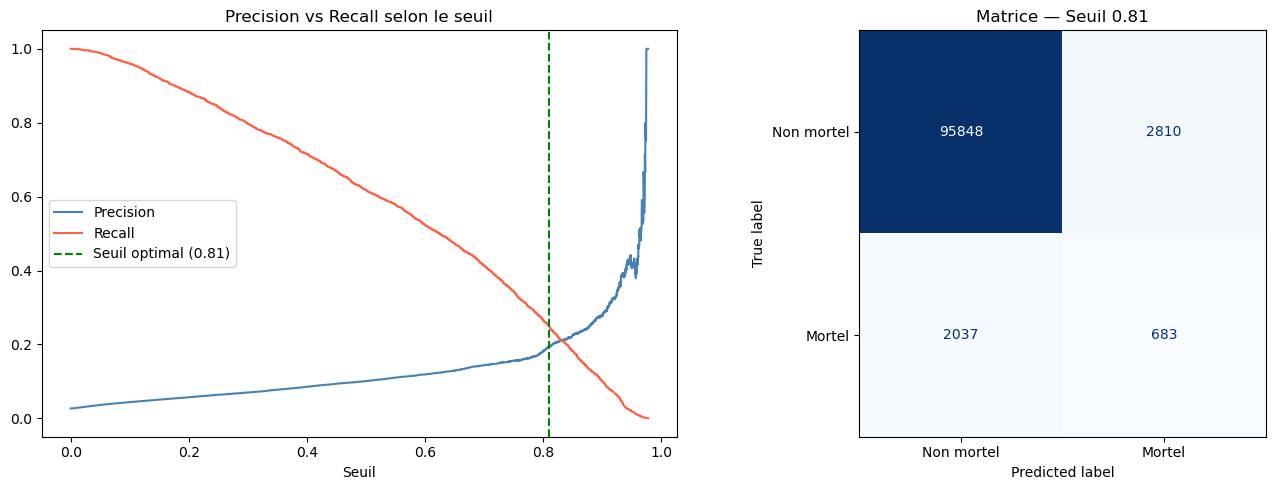

In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

y_proba = rf.predict_proba(X_test)[:, 1]

precisions, recalls, seuils = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
meilleur_seuil = seuils[np.argmax(f1_scores)]
print(f"🎯 Seuil optimal : {meilleur_seuil:.3f}")

y_pred_opt = (y_proba >= meilleur_seuil).astype(int)
print(classification_report(y_test, y_pred_opt,
      target_names=["Non mortel", "Mortel"]))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe Precision / Recall
axes[0].plot(seuils, precisions[:-1], label="Precision", color="steelblue")
axes[0].plot(seuils, recalls[:-1],    label="Recall",    color="tomato")
axes[0].axvline(meilleur_seuil, linestyle="--", color="green",
                label=f"Seuil optimal ({meilleur_seuil:.2f})")
axes[0].set_title("Precision vs Recall selon le seuil")
axes[0].set_xlabel("Seuil")
axes[0].legend()

# Matrice de confusion avec seuil optimisé
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_opt,
    display_labels=["Non mortel", "Mortel"],
    colorbar=False, cmap="Blues", ax=axes[1]
)
axes[1].set_title(f"Matrice — Seuil {meilleur_seuil:.2f}")

plt.tight_layout()
plt.show()

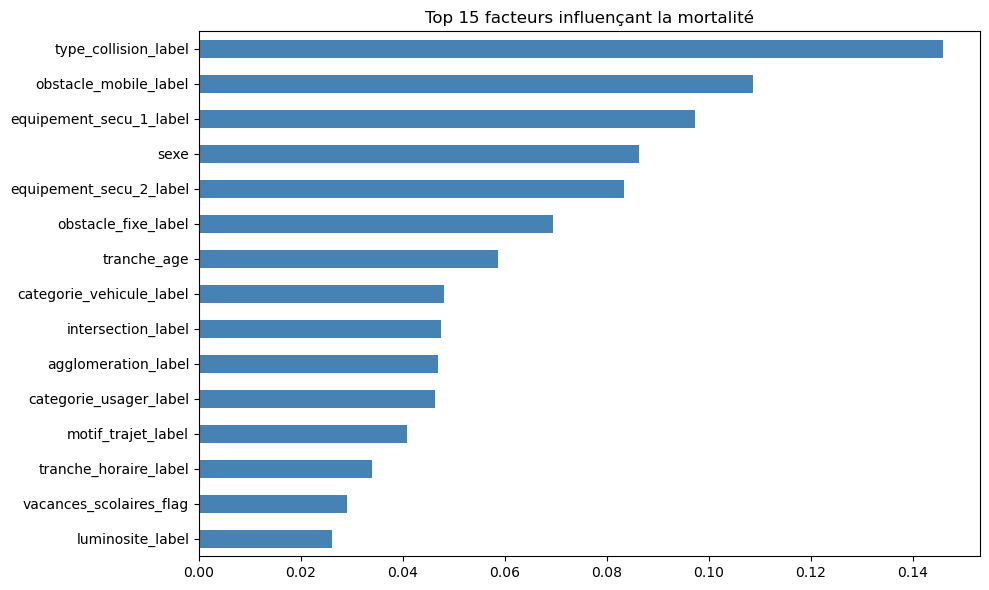

In [ ]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns) \
             .sort_values(ascending=False)

feat_imp.head(15).plot(kind="barh", figsize=(10, 6), color="steelblue")
plt.title("Top 15 facteurs influençant la mortalité")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()